# K-Means Clustering Algorithm - Interview Preparation Guide

## 📚 Table of Contents
1. [Goal and Objective](#goal)
2. [Loss Function](#loss-function)
3. [Algorithm Overview](#algorithm)
4. [Key Concepts for Interviews](#key-concepts)
5. [Implementation](#implementation)

---

## 🎯 Goal and Objective {#goal}

**K-Means is an unsupervised learning algorithm that partitions data into k clusters.**

### Primary Goal:
- **Partition** n data points into k clusters (where k is predefined)
- **Minimize** the within-cluster sum of squares (WCSS), also called **inertia**
- Each data point belongs to the cluster with the **nearest centroid** (mean)

### Key Characteristics:
- **Unsupervised**: No labels needed - we don't know the "correct" clusters
- **Partitioning**: Each point belongs to exactly one cluster (hard clustering)
- **Centroid-based**: Uses the mean of points in a cluster as the cluster center
- **Iterative**: Alternates between assignment and update steps until convergence

### When to Use K-Means:
✅ Data has clear, spherical clusters  
✅ Number of clusters (k) is known or can be estimated  
✅ Clusters are roughly equal in size  
✅ Fast clustering needed for large datasets  

❌ Clusters have irregular shapes  
❌ Clusters have very different sizes  
❌ Number of clusters is unknown  
❌ Outliers are present (K-Means is sensitive to outliers)


## 📉 Loss Function: Within-Cluster Sum of Squares (WCSS) {#loss-function}

### Mathematical Formulation

The **objective function** (what we minimize) is:

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

Where:
- $k$ = number of clusters
- $C_i$ = set of points in cluster $i$
- $\mu_i$ = centroid (mean) of cluster $i$
- $||x - \mu_i||^2$ = squared Euclidean distance from point $x$ to centroid $\mu_i$

### Breaking Down the Loss Function:

1. **For each cluster $i$**: Sum the squared distances from all points in that cluster to the cluster centroid
2. **Sum across all clusters**: Add up the within-cluster sums for all k clusters
3. **Minimize**: The algorithm tries to find centroids that minimize this total sum

### Why Squared Distance?
- **Differentiable**: Makes optimization easier (though K-Means uses a greedy approach)
- **Penalizes outliers**: Large distances are heavily penalized
- **Mathematical convenience**: The mean (centroid) minimizes the sum of squared distances

### Alternative Names:
- **Inertia**: Term used in scikit-learn
- **Within-Cluster Sum of Squares (WCSS)**: More descriptive name
- **Distortion**: Sometimes used in literature

### Interview Question: "Why can't we use absolute distance instead?"
**Answer**: We could, but:
- The mean minimizes squared distances, not absolute distances
- The median minimizes absolute distances
- Using absolute distance would require a different update step (median instead of mean)
- This would be **K-Medians**, not K-Means!


## 🔄 Algorithm Overview {#algorithm}

### K-Means Algorithm Steps:

#### **Step 1: Initialization**
- Randomly select k data points as initial centroids
- **Alternative methods**: K-Means++ (smarter initialization), random initialization

#### **Step 2: Assignment (E-step)**
- For each data point, calculate distance to all k centroids
- Assign point to the **nearest centroid** (minimum distance)
- This creates k clusters

#### **Step 3: Update (M-step)**
- For each cluster, calculate the **mean** of all points assigned to it
- This mean becomes the new centroid
- Move centroids to the center of their clusters

#### **Step 4: Convergence Check**
- Compare new centroids with old centroids
- If centroids moved less than tolerance threshold → **converged** ✅
- If not converged → go back to Step 2

#### **Step 5: Termination**
- Stop when converged OR max iterations reached

### Why This Works (Intuition):

1. **Assignment step** minimizes WCSS for **fixed centroids** (assigns each point to nearest centroid)
2. **Update step** minimizes WCSS for **fixed assignments** (centroid = mean minimizes squared distances)
3. Each step **decreases** the objective function, so algorithm **converges** to a local minimum

### ⚠️ Important Notes:

- **Local Optima**: Algorithm may converge to a suboptimal solution (depends on initialization)
- **Empty Clusters**: Can occur if a centroid has no points assigned (need to handle this)
- **Sensitive to Initialization**: Different starting points → different final clusters
- **Not Guaranteed Global Optimum**: May need multiple runs with different initializations


## 💡 Key Concepts for Interviews {#key-concepts}

### 1. **Time Complexity**
- **Assignment**: O(n × k × d) where n=samples, k=clusters, d=features
- **Update**: O(n × d) - calculating means
- **Per iteration**: O(n × k × d)
- **Overall**: O(n × k × d × i) where i = number of iterations
- Typically converges in < 50 iterations

### 2. **Space Complexity**
- O(n × d) to store data points
- O(k × d) to store centroids
- O(n) to store cluster assignments
- **Total**: O(n × d)

### 3. **Convergence Guarantees**
- ✅ **Always converges** (monotonically decreases objective function)
- ❌ **Not guaranteed global optimum** (only local minimum)
- Solution: Run multiple times with different initializations, pick best result

### 4. **Choosing K (Number of Clusters)**
- **Elbow Method**: Plot inertia vs k, look for "elbow" in curve
- **Domain Knowledge**: Use prior knowledge about data
- **Silhouette Score**: Measure cluster quality (higher = better)
- **Gap Statistic**: Compare with null reference distribution

### 5. **Common Interview Questions**

**Q: What are the assumptions of K-Means?**  
A: 
- Clusters are spherical (circular in 2D)
- Clusters have similar sizes
- Features are equally important (may need scaling)
- Number of clusters (k) is known

**Q: How do you handle empty clusters?**  
A: 
- Reinitialize with a random data point
- Or reinitialize with point farthest from existing centroids
- Or remove the cluster (if k can be reduced)

**Q: What's the difference between K-Means and K-Means++?**  
A: 
- K-Means: Random initialization
- K-Means++: Smart initialization - centroids chosen to be far apart
- K-Means++ reduces chance of poor local optima

**Q: Can K-Means handle non-spherical clusters?**  
A: 
- No, K-Means assumes spherical clusters
- For non-spherical: Use DBSCAN, hierarchical clustering, or kernel K-Means

**Q: Is K-Means deterministic?**  
A: 
- No, due to random initialization
- Same initialization → same result
- Different initialization → potentially different results


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List
import random

class KMeans:
    """
    K-Means Clustering Algorithm Implementation
    
    This is a complete implementation of the K-Means clustering algorithm
    with detailed comments for interview preparation.
    
    Features:
    - Random centroid initialization
    - Iterative assignment and update (Lloyd's algorithm)
    - Convergence detection
    - Empty cluster handling
    - Inertia calculation (loss function)
    """
    
    def __init__(self, k: int, max_iters: int = 100, tol: float = 1e-4, random_seed: int = None):
        """
        Initialize K-Means algorithm
        
        Args:
            k: Number of clusters (must be > 0 and <= n_samples)
            max_iters: Maximum number of iterations before stopping
            tol: Tolerance for convergence - if centroids move less than this, we've converged
            random_seed: Random seed for reproducibility (important for consistent results)
        """
        self.k = k
        self.max_iters = max_iters
        self.tol = tol  # Convergence threshold
        self.centroids = None  # Will store final centroids (k, n_features)
        self.labels = None  # Will store cluster assignments (n_samples,)
        self.inertia_ = None  # Will store final WCSS (within-cluster sum of squares)
        
        # Set random seed for reproducibility (important for debugging and consistent results)
        if random_seed is not None:
            np.random.seed(random_seed)
            random.seed(random_seed)
    
    def _initialize_centroids(self, X: np.ndarray) -> np.ndarray:
        """
        STEP 1: Initialize centroids randomly
        
        This is the initialization step of K-Means. We randomly select k data points
        to serve as initial centroids.
        
        Interview Note: This is the simplest initialization method. Better methods include:
        - K-Means++: Select centroids to be far apart (reduces poor local optima)
        - Random partition: Randomly assign points to clusters, then compute centroids
        
        Args:
            X: Input data of shape (n_samples, n_features)
            
        Returns:
            Centroids of shape (k, n_features) - initial cluster centers
        """
        n_samples, n_features = X.shape
        
        # Randomly select k distinct indices from n_samples
        # replace=False ensures we don't pick the same point twice
        # This gives us k different data points to use as initial centroids
        indices = np.random.choice(n_samples, size=self.k, replace=False)
        
        # Extract the selected data points and copy them (don't modify original data)
        # These become our initial centroids
        centroids = X[indices].copy()
        
        return centroids
    
    def _assign_clusters(self, X: np.ndarray, centroids: np.ndarray) -> np.ndarray:
        """
        STEP 2: Assignment Step (E-step in EM algorithm terminology)
        
        For each data point, find the nearest centroid and assign the point to that cluster.
        This step minimizes the objective function for FIXED centroids.
        
        Interview Note: This is the "E-step" if you think of K-Means as an EM algorithm.
        We're computing the expected cluster assignment for each point.
        
        Mathematical operation:
        - For each point x_i, compute distance to all k centroids
        - Assign x_i to cluster j where distance(x_i, μ_j) is minimum
        - This minimizes: min_j ||x_i - μ_j||^2 for each point
        
        Args:
            X: Input data of shape (n_samples, n_features)
            centroids: Current centroids of shape (k, n_features)
            
        Returns:
            labels: Cluster assignments of shape (n_samples,) - each value is 0 to k-1
        """
        # Calculate Euclidean distance from each point to each centroid
        # Using NumPy broadcasting for efficient computation:
        # 
        # X[:, np.newaxis, :] has shape (n_samples, 1, n_features)
        # centroids[np.newaxis, :, :] has shape (1, k, n_features)
        # 
        # When we subtract them, NumPy broadcasts to (n_samples, k, n_features)
        # This gives us the difference vector for each (point, centroid) pair
        
        # Step-by-step:
        # 1. X[:, np.newaxis, :] - centroids[np.newaxis, :, :] 
        #    → (n_samples, k, n_features) difference vectors
        # 2. ** 2 → square each element (component-wise)
        # 3. .sum(axis=2) → sum over features dimension → (n_samples, k) squared distances
        # 4. np.sqrt(...) → take square root → (n_samples, k) Euclidean distances
        # distances = np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2).sum(axis=2))
        distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        # Now distances[i, j] = Euclidean distance from point i to centroid j
        
        # Assign each point to the nearest centroid
        # argmin finds the index of the minimum value along axis=1 (across centroids)
        # This gives us the cluster index (0 to k-1) for each point
        labels = np.argmin(distances, axis=1)
        
        # labels[i] = cluster index (0 to k-1) that point i belongs to
        return labels
    
    def _update_centroids(self, X: np.ndarray, labels: np.ndarray) -> Tuple[np.ndarray, bool]:
        """
        STEP 3: Update Step (M-step in EM algorithm terminology)
        
        For each cluster, compute the mean of all points assigned to it.
        This mean becomes the new centroid. This step minimizes the objective function
        for FIXED cluster assignments.
        
        Interview Note: Why does the mean minimize squared distances?
        - The mean μ minimizes Σ(x - μ)² (sum of squared distances)
        - This is a fundamental property: mean is the "center of mass" for squared distances
        - If we used absolute distance, we'd need the median instead (K-Medians algorithm)
        
        Mathematical operation:
        - For each cluster j: μ_j = (1/|C_j|) * Σ(x_i for x_i in C_j)
        - This is the centroid update that minimizes WCSS for fixed assignments
        
        Args:
            X: Input data of shape (n_samples, n_features)
            labels: Cluster assignments from assignment step (n_samples,)
            
        Returns:
            Tuple of (new_centroids, has_empty_cluster)
            - new_centroids: Updated centroids (k, n_features)
            - has_empty_cluster: Boolean flag if any cluster has no points
        """
        n_features = X.shape[1]
        new_centroids = np.zeros((self.k, n_features))  # Initialize new centroids
        has_empty_cluster = False
        
        # Update each centroid
        for i in range(self.k):
            # Get all points currently assigned to cluster i
            # labels == i creates a boolean mask, X[labels == i] filters points
            cluster_points = X[labels == i]
            
            # EDGE CASE: Empty cluster handling
            # This can happen if a centroid is far from all points
            # Common interview question: "How do you handle empty clusters?"
            if len(cluster_points) == 0:
                # Strategy: Reinitialize this centroid with a random data point
                # Alternative strategies:
                # 1. Remove the cluster (reduce k)
                # 2. Reinitialize with point farthest from existing centroids
                # 3. Reinitialize with point that has highest distance to its current centroid
                has_empty_cluster = True
                random_idx = np.random.randint(0, len(X))
                new_centroids[i] = X[random_idx]
            else:
                # STANDARD UPDATE: Compute mean of all points in cluster i
                # .mean(axis=0) computes mean along the samples dimension
                # This gives us the centroid (center point) of cluster i
                # 
                # Why mean? Because mean minimizes sum of squared Euclidean distances!
                # This is the optimal update for minimizing WCSS
                new_centroids[i] = cluster_points.mean(axis=0)
        
        return new_centroids, has_empty_cluster
    
    def _has_converged(self, old_centroids: np.ndarray, new_centroids: np.ndarray) -> bool:
        """
        STEP 4: Convergence Check
        
        Check if the algorithm has converged by measuring how much centroids moved.
        If all centroids moved less than the tolerance threshold, we've converged.
        
        Interview Note: Convergence is guaranteed because:
        1. Assignment step decreases WCSS (or keeps it same) for fixed centroids
        2. Update step decreases WCSS (or keeps it same) for fixed assignments
        3. WCSS is bounded below by 0
        4. Therefore, algorithm must converge (though to local, not global, optimum)
        
        Convergence criteria:
        - If max centroid movement < tolerance → converged
        - Alternative: Check if assignments didn't change (no points moved clusters)
        
        Args:
            old_centroids: Previous iteration's centroids (k, n_features)
            new_centroids: Current iteration's centroids (k, n_features)
            
        Returns:
            True if converged (centroids barely moved), False otherwise
        """
        # Calculate how much each centroid moved (Euclidean distance)
        # new_centroids - old_centroids gives displacement vectors (k, n_features)
        # np.linalg.norm(..., axis=1) computes Euclidean norm for each centroid
        # This gives us the movement distance for each of the k centroids
        
        # Find the maximum movement across all centroids
        # If even the most moved centroid moved less than tolerance, we've converged
        max_movement = np.max(np.linalg.norm(new_centroids - old_centroids, axis=1))
        
        # Converged if maximum movement is below tolerance threshold
        return max_movement < self.tol
    
    def fit(self, X: np.ndarray) -> 'KMeans':
        """
        Main Training Loop: Fit K-Means model to data
        
        This implements Lloyd's algorithm (the standard K-Means algorithm):
        1. Initialize centroids
        2. Repeat until convergence:
           a. Assign points to nearest centroids (Assignment step)
           b. Update centroids to be means of assigned points (Update step)
           c. Check for convergence
        
        Interview Note: This is an iterative optimization algorithm.
        Each iteration decreases (or keeps same) the objective function (WCSS).
        Since WCSS is bounded below by 0, the algorithm must converge.
        
        However, convergence is to a LOCAL minimum, not necessarily global minimum!
        This is why initialization matters - different starts → different final clusters.
        
        Args:
            X: Input data of shape (n_samples, n_features)
            
        Returns:
            self (for method chaining)
        """
        # STEP 1: Initialize centroids randomly
        # This is the starting point - different initializations can lead to different results
        self.centroids = self._initialize_centroids(X)
        
        # Main iteration loop - repeat until convergence or max iterations
        for iteration in range(self.max_iters):
            # STEP 2: Assignment Step (E-step)
            # Assign each data point to its nearest centroid
            # This creates k clusters based on current centroids
            self.labels = self._assign_clusters(X, self.centroids)
            
            # STEP 3: Update Step (M-step)
            # Move each centroid to the mean of points assigned to it
            # This minimizes WCSS for the current cluster assignments
            new_centroids, has_empty = self._update_centroids(X, self.labels)
            
            # STEP 4: Convergence Check
            # Check if centroids have stopped moving (converged)
            # If converged, we can stop early (don't need all max_iters iterations)
            if self._has_converged(self.centroids, new_centroids):
                self.centroids = new_centroids
                # Early stopping: algorithm converged before max iterations
                break
            
            # Update centroids for next iteration
            self.centroids = new_centroids
        
        # STEP 5: Calculate final inertia (loss function value)
        # This is the within-cluster sum of squares (WCSS) - what we minimized
        # Lower inertia = tighter clusters = better clustering (generally)
        # Useful for comparing different k values or different runs
        self.inertia_ = self._calculate_inertia(X, self.labels, self.centroids)
        
        return self
    
    def _calculate_inertia(self, X: np.ndarray, labels: np.ndarray, centroids: np.ndarray) -> float:
        """
        Calculate the Loss Function: Within-Cluster Sum of Squares (WCSS / Inertia)
        
        This is the objective function that K-Means minimizes:
        J = Σ(i=1 to k) Σ(x in C_i) ||x - μ_i||²
        
        Where:
        - k = number of clusters
        - C_i = set of points in cluster i
        - μ_i = centroid (mean) of cluster i
        - ||x - μ_i||² = squared Euclidean distance
        
        Interview Note: This is what we're optimizing! Lower inertia = better clustering.
        However, inertia always decreases as k increases (more clusters = tighter fit).
        So we can't just minimize inertia - we need to balance with number of clusters.
        
        Args:
            X: Input data (n_samples, n_features)
            labels: Cluster assignments (n_samples,)
            centroids: Cluster centroids (k, n_features)
            
        Returns:
            inertia: Total within-cluster sum of squares (the loss we minimized)
        """
        inertia = 0.0
        
        # For each cluster, sum the squared distances from points to centroid
        for i in range(self.k):
            # Get all points in cluster i
            cluster_points = X[labels == i]
            
            if len(cluster_points) > 0:
                # Calculate squared Euclidean distances from each point to centroid i
                # cluster_points - centroids[i] gives difference vectors
                # ** 2 squares each component
                # np.sum() sums all squared distances for this cluster
                squared_distances = np.sum((cluster_points - centroids[i]) ** 2)
                
                # Add to total inertia (sum across all clusters)
                inertia += squared_distances
        
        # Return total inertia (the objective function value)
        return inertia
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict cluster assignments for new (unseen) data points
        
        For K-Means, prediction is simple: assign each new point to its nearest centroid.
        This is the same as the assignment step in training, but we don't update centroids.
        
        Interview Note: K-Means is a "lazy" learner in the sense that:
        - Training: Just stores centroids (very fast)
        - Prediction: Computes distances to all centroids (O(k × d) per point)
        - No complex model parameters to learn
        
        Args:
            X: New data points of shape (n_samples, n_features)
            
        Returns:
            labels: Cluster assignments (n_samples,) - each value is 0 to k-1
        """
        # Safety check: must fit model before predicting
        if self.centroids is None:
            raise ValueError("Model must be fitted before prediction")
        
        # Prediction is just assignment: find nearest centroid for each point
        # We use the same assignment logic as in training
        return self._assign_clusters(X, self.centroids)

K-MEANS CLUSTERING RESULTS
Number of data points: 300
Final inertia (WCSS): 540.29

Final centroids (cluster centers):
  Cluster 0: [1.8731, 1.9761]
  Cluster 1: [1.8737, -2.2151]
  Cluster 2: [-1.9714, -1.9649]


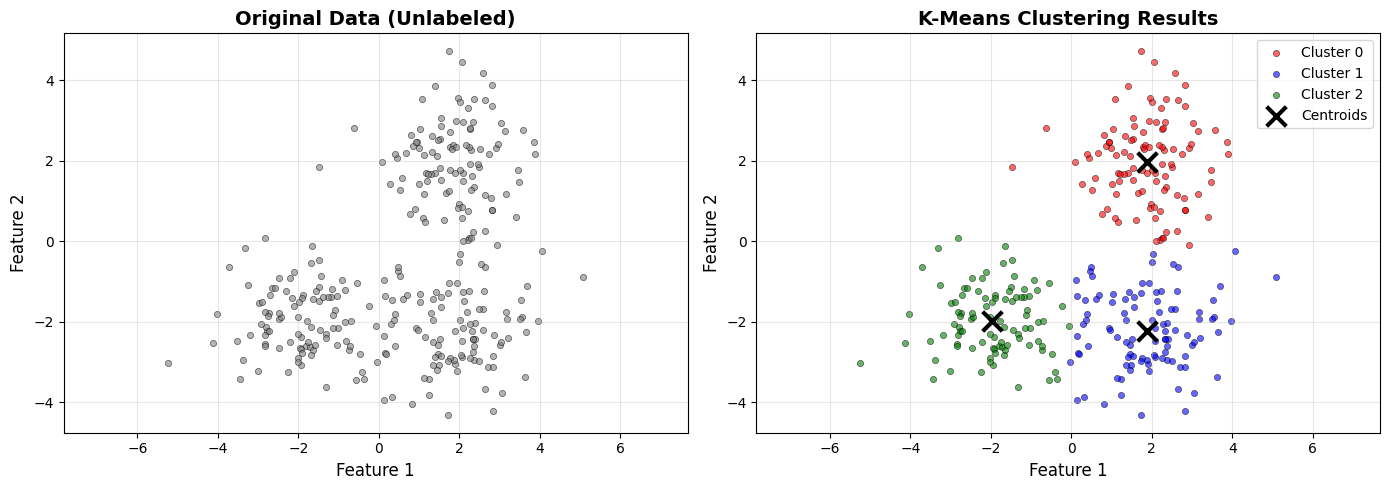


PREDICTIONS FOR NEW DATA POINTS
  Point [  0,   0] → Cluster 0
  Point [  3,   3] → Cluster 0
  Point [ -3,  -3] → Cluster 2


In [4]:
# ============================================================================
# EXAMPLE: K-Means Clustering Demonstration
# ============================================================================
# This example demonstrates the complete K-Means workflow:
# 1. Generate synthetic data with known clusters
# 2. Fit K-Means model
# 3. Visualize results
# 4. Make predictions on new data
# ============================================================================

# Generate synthetic 2D data with 3 well-separated clusters
# This simulates a real-world scenario where we know there are 3 groups
np.random.seed(42)

# Cluster 1: Centered at (2, 2) with standard normal distribution
cluster1 = np.random.randn(100, 2) + [2, 2]

# Cluster 2: Centered at (-2, -2) with standard normal distribution
cluster2 = np.random.randn(100, 2) + [-2, -2]

# Cluster 3: Centered at (2, -2) with standard normal distribution
cluster3 = np.random.randn(100, 2) + [2, -2]

# Combine all clusters into one dataset
X = np.vstack([cluster1, cluster2, cluster3])
# X now has shape (300, 2) - 300 points in 2D space

# ============================================================================
# TRAINING: Fit K-Means model
# ============================================================================
# Create K-Means model with k=3 (we know there are 3 clusters)
kmeans = KMeans(k=3, max_iters=100, tol=1e-4, random_seed=42)

# Fit the model to the data
# This runs the iterative algorithm until convergence
kmeans.fit(X)

# ============================================================================
# RESULTS: Print clustering results
# ============================================================================
print("=" * 60)
print("K-MEANS CLUSTERING RESULTS")
print("=" * 60)
print(f"Number of data points: {len(kmeans.labels)}")
print(f"Final inertia (WCSS): {kmeans.inertia_:.2f}")
print(f"\nFinal centroids (cluster centers):")
for i, centroid in enumerate(kmeans.centroids):
    print(f"  Cluster {i}: [{centroid[0]:.4f}, {centroid[1]:.4f}]")
print("=" * 60)

# ============================================================================
# VISUALIZATION: Compare original data vs clustered results
# ============================================================================
plt.figure(figsize=(14, 5))

# Plot 1: Original unlabeled data
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.6, s=20, edgecolors='black', linewidths=0.5)
plt.title('Original Data (Unlabeled)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 2: Clustered data with centroids
plt.subplot(1, 2, 2)
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

# Plot each cluster with different color
for i in range(kmeans.k):
    cluster_points = X[kmeans.labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i % len(colors)], label=f'Cluster {i}', 
                alpha=0.6, s=20, edgecolors='black', linewidths=0.5)

# Plot centroids (cluster centers) as black X markers
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], 
           c='black', marker='x', s=200, linewidths=3, 
           label='Centroids', zorder=10)

plt.title('K-Means Clustering Results', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.show()

# ============================================================================
# PREDICTION: Assign new data points to clusters
# ============================================================================
# Test the model on new, unseen data points
new_points = np.array([[0, 0],    # Point between clusters
                       [3, 3],    # Point near cluster 1
                       [-3, -3]]) # Point near cluster 2

# Predict cluster assignments for new points
predictions = kmeans.predict(new_points)

print("\n" + "=" * 60)
print("PREDICTIONS FOR NEW DATA POINTS")
print("=" * 60)
for point, pred in zip(new_points, predictions):
    print(f"  Point [{point[0]:3.0f}, {point[1]:3.0f}] → Cluster {pred}")
print("=" * 60)

# ============================================================================
# INTERVIEW NOTES:
# ============================================================================
# 1. The algorithm successfully identified 3 clusters
# 2. Centroids are close to the true cluster centers (2,2), (-2,-2), (2,-2)
# 3. Inertia measures how "tight" the clusters are (lower = better)
# 4. New points are assigned to nearest centroid (same as training assignment step)
# ============================================================================


## 📋 Interview Preparation Summary

### Quick Reference: K-Means Algorithm

**Goal**: Partition n points into k clusters to minimize within-cluster sum of squares

**Algorithm (Lloyd's Algorithm)**:
1. **Initialize**: Randomly select k centroids
2. **Assign**: Assign each point to nearest centroid
3. **Update**: Move centroids to mean of assigned points
4. **Repeat**: Steps 2-3 until convergence

**Loss Function**: 
$$J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

**Time Complexity**: O(n × k × d × i) where i = iterations  
**Space Complexity**: O(n × d)

### Key Interview Answers

**Q: How does K-Means work?**  
A: Iteratively alternates between assigning points to nearest centroids and updating centroids to be means of assigned points. Minimizes within-cluster sum of squares.

**Q: Why does it converge?**  
A: Each step decreases (or keeps same) the objective function. Since WCSS is bounded below by 0, algorithm must converge to a local minimum.

**Q: What are limitations?**  
A: Assumes spherical clusters, sensitive to initialization, requires k to be specified, sensitive to outliers, doesn't handle non-convex clusters.

**Q: How to choose k?**  
A: Elbow method (plot inertia vs k), domain knowledge, silhouette score, gap statistic, or cross-validation if labels available.

**Q: K-Means vs K-Means++?**  
A: K-Means++ uses smarter initialization (centroids far apart) to reduce chance of poor local optima. Same algorithm, better starting point.

### Common Mistakes to Avoid

❌ Forgetting to scale features (K-Means is distance-based!)  
❌ Using even k when you have 2 classes (can cause ties)  
❌ Not handling empty clusters  
❌ Assuming global optimum (only local minimum guaranteed)  
❌ Using K-Means for non-spherical clusters  

### Practice Questions

1. Implement K-Means from scratch
2. Explain why mean (not median) is used for centroid update
3. How would you modify K-Means to handle outliers?
4. What happens if k > n (number of samples)?
5. How does K-Means relate to EM algorithm?

---

**Good luck with your interviews! 🚀**
